In [1]:
!pip install pyspark

In [2]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("EmailSpamDetection") \
    .getOrCreate()

spark

In [69]:
import pandas as pd

pdf = pd.read_csv("/content/spam.csv", encoding='latin-1')
pdf.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [51]:
pdf.columns

Index(['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], dtype='object')

In [52]:
pdf = pdf[['v1', 'v2']]
pdf.columns = ['label', 'text']

In [70]:
pdf = pdf.dropna()
pdf = pdf.drop_duplicates()
pdf.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
281,ham,\Wen u miss someone,the person is definitely special for u..... B...,why to miss them,"just Keep-in-touch\"" gdeve.."""
1038,ham,"Edison has rightly said, \A fool can ask more ...",GN,GE,"GNT:-)"""
2255,ham,I just lov this line: \Hurt me with the truth,I don't mind,i wil tolerat.bcs ur my someone..... But,"Never comfort me with a lie\"" gud ni8 and swe..."
3525,ham,\HEY BABE! FAR 2 SPUN-OUT 2 SPK AT DA MO... DE...,HAD A COOL NYTHO,TX 4 FONIN HON,"CALL 2MWEN IM BK FRMCLOUD 9! J X\"""""
4668,ham,"When I was born, GOD said, \Oh No! Another IDI...",GOD said,"\""OH No! COMPETITION\"". Who knew","one day these two will become FREINDS FOREVER!"""


In [55]:
pdf['label'] = pdf['label'].str.lower()
pdf['label'] = pdf['label'].map({'spam': 1, 'ham': 0})

In [56]:
pdf['label'].value_counts()

,count
label,
0,4516
1,653


In [71]:
wordsData.select("words").show(5, truncate=False)

+----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|words                                                                                                                                                                                   |
+----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|[go, until, jurong, point,, crazy.., available, only, in, bugis, n, great, world, la, e, buffet..., cine, there, got, amore, wat...]                                                    |
|[ok, lar..., joking, wif, u, oni...]                                                                                                                                                    |
|[free, entry, in, 2, a, wkly, comp, to, win, fa, cup, final, tkt

In [72]:
cleanData.select("filtered").show(5, truncate=False)

+---------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|filtered                                                                                                                                                             |
+---------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|[go, jurong, point,, crazy.., available, bugis, n, great, world, la, e, buffet..., cine, got, amore, wat...]                                                         |
|[ok, lar..., joking, wif, u, oni...]                                                                                                                                 |
|[free, entry, 2, wkly, comp, win, fa, cup, final, tkts, 21st, may, 2005., text, fa, 87121, receive, entry, question(std, txt, rate)t&c's, apply, 08452810075ove

In [73]:
featurizedData.select("rawFeatures").show(5, truncate=False)

+--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|rawFeatures                                                                                                                                                                                                                                 |
+--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|(262144,[38555,52644,58325,60080,73184,95595,134335,140762,148675,156185,167694,189968,197089,204971,225898,261870],[1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0])                                                      |
|(262144,[51783,154627,170710,198197,205807,

In [74]:
finalData.select("features").show(5, truncate=False)

+--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|features                                                                                                                                                                                                                                                                                                                                                                                                                                                                          

In [75]:
print("Logistic Regression Model Trained Successfully")

Logistic Regression Model Trained Successfully


In [76]:
predictions.select("text", "label", "prediction").show(10, truncate=False)

+----------------------------------------------------------------------------------------------------------------------------------------------------------------+-----+----------+
|text                                                                                                                                                            |label|prediction|
+----------------------------------------------------------------------------------------------------------------------------------------------------------------+-----+----------+
|Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...                                                 |0    |0.0       |
|Ok lar... Joking wif u oni...                                                                                                                                   |0    |0.0       |
|Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive ent

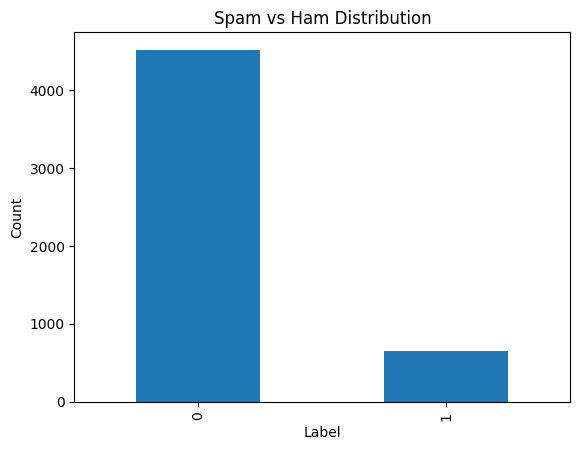

In [57]:
import matplotlib.pyplot as plt

pdf['label'].value_counts().plot(kind='bar')
plt.title("Spam vs Ham Distribution")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()

In [58]:
from pyspark.sql import SparkSession

spark = SparkSession.builder.appName("SpamDetection").getOrCreate()

df = spark.createDataFrame(pdf)
df.show(5)

+-----+--------------------+
|label|                text|
+-----+--------------------+
|    0|Go until jurong p...|
|    0|Ok lar... Joking ...|
|    1|Free entry in 2 a...|
|    0|U dun say so earl...|
|    0|Nah I don't think...|
+-----+--------------------+
only showing top 5 rows


In [60]:
from pyspark.ml.feature import Tokenizer, StopWordsRemover

tokenizer = Tokenizer(inputCol="text", outputCol="words")
wordsData = tokenizer.transform(df)

remover = StopWordsRemover(inputCol="words", outputCol="filtered")
cleanData = remover.transform(wordsData)

In [61]:
from pyspark.ml.feature import HashingTF, IDF

tf = HashingTF(inputCol="filtered", outputCol="rawFeatures")
featurizedData = tf.transform(cleanData)

idf = IDF(inputCol="rawFeatures", outputCol="features")
idfModel = idf.fit(featurizedData)
finalData = idfModel.transform(featurizedData)

In [62]:
from pyspark.ml.classification import LogisticRegression

lr = LogisticRegression(featuresCol="features", labelCol="label")
model = lr.fit(finalData)

In [63]:
predictions = model.transform(finalData)
predictions.select("text", "label", "prediction").show(10)

+--------------------+-----+----------+
|                text|label|prediction|
+--------------------+-----+----------+
|Go until jurong p...|    0|       0.0|
|Ok lar... Joking ...|    0|       0.0|
|Free entry in 2 a...|    1|       1.0|
|U dun say so earl...|    0|       0.0|
|Nah I don't think...|    0|       0.0|
|FreeMsg Hey there...|    1|       1.0|
|Even my brother i...|    0|       0.0|
|As per your reque...|    0|       0.0|
|WINNER!! As a val...|    1|       1.0|
|Had your mobile 1...|    1|       1.0|
+--------------------+-----+----------+
only showing top 10 rows


In [64]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

evaluator = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="accuracy"
)

accuracy = evaluator.evaluate(predictions)
print("Accuracy:", accuracy)

Accuracy: 1.0


In [65]:
from pyspark.ml.classification import NaiveBayes

nb = NaiveBayes(featuresCol="features", labelCol="label")
nb_model = nb.fit(finalData)

nb_predictions = nb_model.transform(finalData)

accuracy_nb = evaluator.evaluate(nb_predictions)
print("Naive Bayes Accuracy:", accuracy_nb)

Naive Bayes Accuracy: 0.9974850067711356


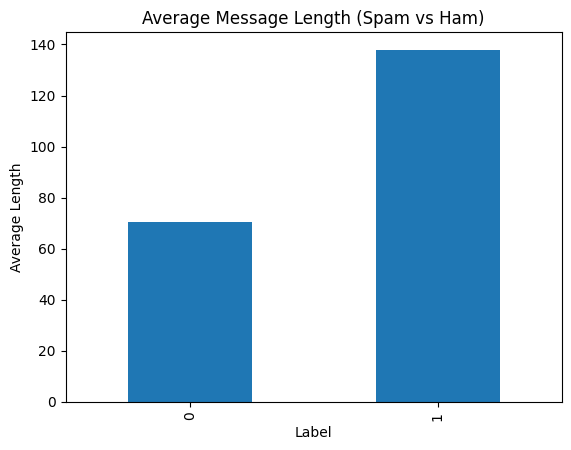

In [66]:
pdf['length'] = pdf['text'].apply(len)

pdf.groupby('label')['length'].mean().plot(kind='bar')
plt.title("Average Message Length (Spam vs Ham)")
plt.xlabel("Label")
plt.ylabel("Average Length")
plt.show()

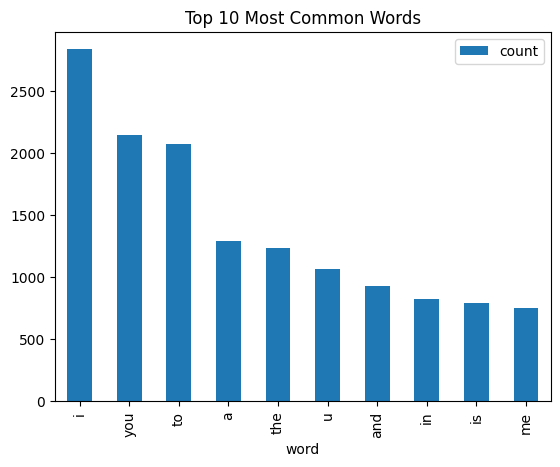

In [67]:
from collections import Counter
import re

all_words = ' '.join(pdf['text'])
words = re.findall(r'\w+', all_words.lower())

common_words = Counter(words).most_common(10)

words_df = pd.DataFrame(common_words, columns=['word', 'count'])

words_df.plot(x='word', y='count', kind='bar')
plt.title("Top 10 Most Common Words")
plt.show()

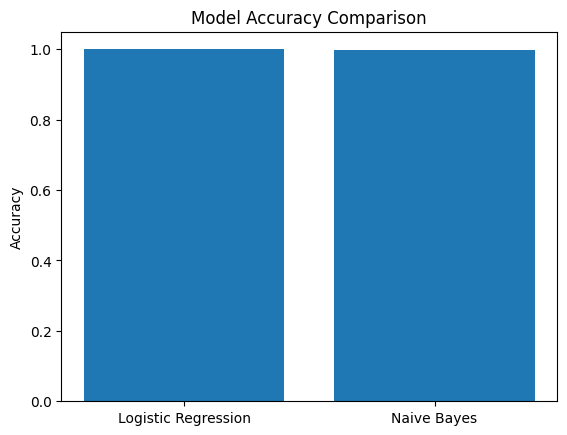

In [68]:
models = ['Logistic Regression', 'Naive Bayes']
accuracy_scores = [accuracy, accuracy_nb]

plt.bar(models, accuracy_scores)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()

import org.apache.spark.sql.SparkSession

val spark = SparkSession.builder()
  .appName("Email Spam Detection")
  .master("local[*]")
  .getOrCreate()

val df = spark.read
  .option("header", "true")
  .option("inferSchema", "true")
  .csv("spam.csv")

df.show(5)